In [2]:
# ─── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from scipy import signal as scipy_signal

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor":   "#1a1a1a",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "#ccc",
    "xtick.color":      "#aaa",
    "ytick.color":      "#aaa",
    "text.color":       "#eee",
    "grid.color":       "#333",
    "grid.linestyle":   "--",
    "grid.alpha":       0.4,
})
print("✓ Imports ready")

✓ Imports ready


In [3]:
# ─── Cell 2: QAMMapper ────────────────────────────────────────────────────────

class QAMMapper:
    """
    Gray-coded QAM constellation mapper and hard-decision demapper.
    Supported: 'BPSK', 'QPSK', '16-QAM', '64-QAM'

    ── What is Gray Coding? ────────────────────────────────────────────────────
    Standard binary counting:  00, 01, 10, 11
    Gray code ordering:        00, 01, 11, 10

    In Gray code, adjacent values differ by exactly ONE bit.
    In QAM, "adjacent" means nearest neighbors in the I-Q plane.

    Why this matters for BER:
    When noise pushes a received symbol into the wrong decision region,
    it almost always lands in a *neighboring* region. Gray coding ensures
    that neighbor error = 1 bit error, not 2 or 3. Without Gray coding,
    BER at moderate SNR would be ~2× worse.

    ── Square QAM Structure ────────────────────────────────────────────────────
    For M-QAM (M = 4, 16, 64), we use two independent PAM signals:
      - MSBs (upper half of bits) → In-Phase (I, real axis)
      - LSBs (lower half of bits) → Quadrature (Q, imaginary axis)

    Each PAM dimension uses Gray-coded levels: {-3,-1,+1,+3} for 16-QAM.
    Normalization sets average symbol power = 1.0 across all schemes.
    """

    SCHEMES = ['BPSK', 'QPSK', '16-QAM', '64-QAM']
    COLORS  = {
        'BPSK':   '#5DCAA5',
        'QPSK':   '#378ADD',
        '16-QAM': '#EF9F27',
        '64-QAM': '#D85A30',
    }

    def __init__(self, scheme: str):
        if scheme not in self.SCHEMES:
            raise ValueError(f"scheme must be one of {self.SCHEMES}")
        self.scheme = scheme
        self._build_constellation()

    # ── Gray Code Utilities ──────────────────────────────────────────────────

    @staticmethod
    def _to_gray(n: int) -> int:
        """Natural binary → Gray code.  e.g. 3 (11) → 2 (10)"""
        return n ^ (n >> 1)

    @staticmethod
    def _from_gray(g: int) -> int:
        """
        Gray code → natural binary  (inverse of _to_gray).
        Used to find the PAM array index from a Gray-coded bit group.
        e.g. g=3 (11) → natural index 2
        """
        n, mask = g, g >> 1
        while mask:
            n    ^= mask
            mask >>= 1
        return n

    # ── Constellation Builder ────────────────────────────────────────────────

    def _build_constellation(self):
        """
        Generate the full  {bit_integer → complex_symbol}  lookup table.

        Algorithm for square M-QAM:
          1. Compute PAM levels for sqrt(M)-PAM: {-(√M-1), ..., +1, ..., +(√M-1)}
             e.g. √M=4 → [-3, -1, +1, +3]
          2. Measure average power per dimension → normalization factor
          3. For each of the M bit patterns:
               a. Split into k_half MSBs (→ I) and k_half LSBs (→ Q)
               b. Gray-decode each half to get the PAM array index
               c. Look up the PAM level, normalize, form complex symbol
        """
        if self.scheme == 'BPSK':
            self.bits_per_symbol = 1
            self.M               = 2
            self.norm_factor     = 1.0
            # Simple two-point BPSK: 0 → -1, 1 → +1 (on real axis)
            self.constellation   = {0: complex(-1, 0), 1: complex(+1, 0)}

        else:
            self.M               = 4 if self.scheme == 'QPSK' else int(self.scheme.split('-')[0])
            self.bits_per_symbol = int(np.log2(self.M))
            sqrt_M               = int(np.sqrt(self.M))
            k                    = self.bits_per_symbol // 2  # bits per axis

            # ── PAM levels for one dimension ─────────────────────────────
            # General formula: level_i = -(√M - 1) + 2i,  i = 0,1,...,√M-1
            # QPSK:   √M=2  → [-1, +1]
            # 16-QAM: √M=4  → [-3, -1, +1, +3]
            # 64-QAM: √M=8  → [-7, -5, -3, -1, +1, +3, +5, +7]
            pam_levels = [-(sqrt_M - 1) + 2 * i for i in range(sqrt_M)]

            # ── Normalization ─────────────────────────────────────────────
            # Average power per dim = E[level²]
            # Total avg power = 2 × per_dim  (I² + Q²)
            # We want total avg power = 1, so divide by √(2 × per_dim)
            avg_power_per_dim = np.mean([lv ** 2 for lv in pam_levels])
            self.norm_factor  = np.sqrt(2 * avg_power_per_dim)
            # Verification: norm_factor = √2 (QPSK), √10 (16-QAM), √42 (64-QAM)

            # ── Build table ───────────────────────────────────────────────
            self.constellation = {}
            for bit_int in range(self.M):

                # Split the bit integer: upper k bits → I, lower k bits → Q
                i_gray = (bit_int >> k) & ((1 << k) - 1)
                q_gray =  bit_int       & ((1 << k) - 1)

                # Gray decode → PAM array index
                # This maps the user's bit pattern to the correct PAM level
                # while preserving the Gray-code neighbor property
                i_idx  = self._from_gray(i_gray)
                q_idx  = self._from_gray(q_gray)

                I = pam_levels[i_idx]
                Q = pam_levels[q_idx]

                self.constellation[bit_int] = complex(I, Q) / self.norm_factor

        # ── Arrays for vectorized nearest-neighbor lookup ────────────────
        sorted_keys        = sorted(self.constellation.keys())
        self._sym_array    = np.array([self.constellation[k] for k in sorted_keys])
        self._key_array    = np.array(sorted_keys, dtype=int)

    # ── Modulation ───────────────────────────────────────────────────────────

    def modulate(self, bits: np.ndarray) -> np.ndarray:
        """
        Bit array → complex QAM symbol array.

        Steps per symbol:
          1. Grab the next `bits_per_symbol` bits
          2. Convert bit group to integer (MSB first)
          3. Look up complex symbol in the constellation table

        Args:
            bits: 1D int array (0/1). len(bits) must be divisible by bits_per_symbol.
        Returns:
            symbols: 1D complex array, length = len(bits) / bits_per_symbol.
        """
        bps = self.bits_per_symbol
        if len(bits) % bps != 0:
            raise ValueError(
                f"{self.scheme} needs bit count divisible by {bps}. "
                f"Got {len(bits)}. "
                f"Trim to {(len(bits) // bps) * bps} or pad with zeros."
            )

        n_syms  = len(bits) // bps
        symbols = np.empty(n_syms, dtype=complex)

        for i in range(n_syms):
            chunk   = bits[i * bps: (i + 1) * bps]
            # Convert bit array [b0, b1, ..., bn] → integer (b0 is MSB)
            bit_int = 0
            for b in chunk:
                bit_int = (bit_int << 1) | int(b)
            symbols[i] = self.constellation[bit_int]

        return symbols

    # ── Demodulation ─────────────────────────────────────────────────────────

    def demodulate(self, symbols: np.ndarray) -> np.ndarray:
        """
        Hard-decision nearest-neighbor QAM demodulation.

        For each received complex symbol r, find the constellation point c*
        that minimizes |r - c|².  Output the bit label of c*.

        "Hard decision" = we commit to a 0/1 immediately based on distance.
        (Phase 3 will eventually add soft decisions for LDPC decoding.)

        Vectorized using broadcasting: O(N_symbols × M) operations.
        """
        bps  = self.bits_per_symbol

        # ── Vectorized Euclidean distance ─────────────────────────────────
        # symbols:       (N,)  → reshape to (N, 1)
        # _sym_array:    (M,)  → broadcast to (N, M)
        # distances:     (N, M) — squared distance to every constellation point
        distances   = np.abs(symbols[:, np.newaxis] - self._sym_array[np.newaxis, :]) ** 2
        best_idx    = np.argmin(distances, axis=1)   # (N,) — index of nearest point
        bit_ints    = self._key_array[best_idx]      # (N,) — integer label

        # ── Unpack each integer to its bit representation ─────────────────
        bits = np.zeros(len(symbols) * bps, dtype=int)
        for i, bit_int in enumerate(bit_ints):
            for b in range(bps):
                bits[i * bps + b] = (int(bit_int) >> (bps - 1 - b)) & 1

        return bits

    # ── Utilities ─────────────────────────────────────────────────────────────

    def get_constellation_points(self):
        """Return (symbols, bit_labels) for all constellation points."""
        labels = [f"{k:0{self.bits_per_symbol}b}" for k in self._key_array]
        return self._sym_array.copy(), labels

    def __repr__(self):
        return (
            f"QAMMapper(scheme={self.scheme!r}, "
            f"bits_per_symbol={self.bits_per_symbol}, "
            f"M={self.M}, "
            f"norm_factor={self.norm_factor:.4f})"
        )


# ── Quick sanity check ────────────────────────────────────────────────────────
for s in QAMMapper.SCHEMES:
    m = QAMMapper(s)
    syms = m._sym_array
    avg_pwr = np.mean(np.abs(syms) ** 2)
    print(f"{s:<10}  bits/sym={m.bits_per_symbol}  M={m.M:>2}  "
          f"avg_power={avg_pwr:.6f}  (should be 1.0)")

BPSK        bits/sym=1  M= 2  avg_power=1.000000  (should be 1.0)
QPSK        bits/sym=2  M= 4  avg_power=1.000000  (should be 1.0)
16-QAM      bits/sym=4  M=16  avg_power=1.000000  (should be 1.0)
64-QAM      bits/sym=6  M=64  avg_power=1.000000  (should be 1.0)


In [3]:
# ─── Cell 3: OFDM System Configuration ───────────────────────────────────────

class OFDMConfig:
    """
    All OFDM system parameters in one place.
    Modeled after IEEE 802.11a (Wi-Fi 1) with N_fft=64.

    ── Subcarrier Layout (FFT bin index 0 to 63) ───────────────────────────────

         Bin 0      :  DC null   — avoids LO leakage (hardware artifact)
         Bins 1–26  :  Positive-frequency active subcarriers  (26 bins)
         Bins 27–37 :  Upper guard band — null  (spectral containment)
         Bins 38–63 :  Negative-frequency active subcarriers  (26 bins)
                        (NumPy FFT convention: negative freqs wrap to end)
         Total active = 52  |  4 pilots  |  48 data

         Why guard bands?
         Without them, OFDM's rectangular windowing creates sinc sidelobes
         that spill into adjacent channels. Guard bands are the "quiet zones"
         separating your signal from your neighbor's.

    ── Why Cyclic Prefix? ───────────────────────────────────────────────────────
         The CP copies the LAST CP_len samples and prepends them:
           [s[N-16], ..., s[N-1], s[0], s[1], ..., s[N-1]]
               ↑ CP (16 samples) ↑       ↑ OFDM symbol (64) ↑

         Effect 1: Absorbs multipath delay spread up to CP_len samples.
                   Each multipath echo arrives before the FFT window starts.
         Effect 2: Makes linear channel convolution look circular.
                   Circular convolution in time = pointwise multiply in freq.
                   So one-tap equalization per subcarrier is sufficient.
         Cost:     CP_len/symbol_duration = 16/80 = 20% throughput overhead.

    ── Why Pilots? ──────────────────────────────────────────────────────────────
         Known symbols at fixed positions let the receiver measure how the
         channel has distorted the signal (amplitude × phase per subcarrier).
         In Phase 3, we'll use pilots to build a channel estimate H[k]
         and divide each data subcarrier by H[k] to undo the distortion.
    """

    def __init__(
        self,
        N_fft:        int     = 64,
        CP_len:       int     = 16,
        pilot_bins:   list    = None,
        pilot_symbol: complex = 1 + 0j,
    ):
        self.N_fft        = N_fft
        self.CP_len       = CP_len
        self.pilot_symbol = pilot_symbol

        # ── Pilot bin positions ──────────────────────────────────────────
        # Default: 802.11a pilot positions at ±7 and ±21 relative to DC
        # In FFT bin notation: positive=7,21 / negative=64-21=43, 64-7=57
        self.pilot_bins = pilot_bins if pilot_bins is not None else [7, 21, 43, 57]

        # ── Active subcarrier bins ───────────────────────────────────────
        n_side            = N_fft // 2 - (N_fft // 2 - 27)  # 26 bins per side
        pos_bins          = list(range(1, 27))                # bins 1..26
        neg_bins          = list(range(N_fft - 26, N_fft))   # bins 38..63
        self.active_bins  = pos_bins + neg_bins               # 52 total

        # ── Data bins = active - pilots ──────────────────────────────────
        pilot_set         = set(self.pilot_bins)
        self.data_bins    = [b for b in self.active_bins if b not in pilot_set]

        # ── Derived scalars ──────────────────────────────────────────────
        self.N_data         = len(self.data_bins)       # 48
        self.N_pilots       = len(self.pilot_bins)      # 4
        self.N_active       = len(self.active_bins)     # 52
        self.N_guard        = N_fft - self.N_active     # 12 (DC + guard bands)
        self.symbol_duration = N_fft + CP_len           # 80 samples

    def print_summary(self):
        print(f"\n{'='*52}")
        print(f"  OFDM System Configuration  (802.11a-style)")
        print(f"{'='*52}")
        print(f"  FFT size          : {self.N_fft} points")
        print(f"  Cyclic prefix     : {self.CP_len} samples  "
              f"({self.CP_len/self.symbol_duration*100:.0f}% overhead)")
        print(f"  Symbol duration   : {self.symbol_duration} samples")
        print(f"{'─'*52}")
        print(f"  Total subcarriers : {self.N_fft}")
        print(f"  Active            : {self.N_active}")
        print(f"  ├── Data          : {self.N_data}")
        print(f"  └── Pilots        : {self.N_pilots}  {self.pilot_bins}")
        print(f"  DC + Guard        : {self.N_guard}")
        print(f"{'─'*52}")
        for scheme in QAMMapper.SCHEMES:
            bps      = QAMMapper(scheme).bits_per_symbol
            capacity = self.N_data * bps
            print(f"  {scheme:<10}  →  {capacity:>4} bits/OFDM symbol  "
                  f"({self.N_data} × {bps})")
        print(f"{'='*52}\n")


cfg = OFDMConfig()
cfg.print_summary()


  OFDM System Configuration  (802.11a-style)
  FFT size          : 64 points
  Cyclic prefix     : 16 samples  (20% overhead)
  Symbol duration   : 80 samples
────────────────────────────────────────────────────
  Total subcarriers : 64
  Active            : 52
  ├── Data          : 48
  └── Pilots        : 4  [7, 21, 43, 57]
  DC + Guard        : 12
────────────────────────────────────────────────────
  BPSK        →    48 bits/OFDM symbol  (48 × 1)
  QPSK        →    96 bits/OFDM symbol  (48 × 2)
  16-QAM      →   192 bits/OFDM symbol  (48 × 4)
  64-QAM      →   288 bits/OFDM symbol  (48 × 6)



In [4]:
# ─── Cell 4: OFDM Modulator (TX Chain) ───────────────────────────────────────

class OFDMModulator:
    """
    TX Chain: bits → OFDM time-domain signal

    Step-by-step:
      [1] QAM Map     : bits → complex symbols
      [2] S/P         : serialize symbols into a 2D matrix (n_ofdm × N_data)
      [3] Subcarrier  : scatter symbols into an N_fft-point freq-domain frame
          Mapping       (data → data bins, pilot_symbol → pilot bins, 0 elsewhere)
      [4] IFFT        : freq domain → time domain  (this IS the OFDM modulation)
      [5] Add CP      : prepend last CP_len samples to each symbol
      [6] P/S         : flatten all OFDM symbols to 1D output stream
    """

    def __init__(self, config: OFDMConfig, mapper: QAMMapper):
        self.cfg    = config
        self.mapper = mapper

    def modulate(self, bits: np.ndarray) -> np.ndarray:
        """
        Full TX chain: bits → tx_signal.

        If len(bits) is not an exact multiple of (bits_per_symbol × N_data),
        it is zero-padded to the next whole OFDM symbol boundary.
        This is exactly what real systems do (padding is marked as "filler").

        Returns:
            tx_signal: 1D complex array of length n_ofdm × symbol_duration.
        """
        bps               = self.mapper.bits_per_symbol
        bits_per_ofdm_sym = bps * self.cfg.N_data   # e.g., 4 × 48 = 192 for 16-QAM

        # ── Zero-pad to whole OFDM symbol boundary ───────────────────────
        remainder = len(bits) % bits_per_ofdm_sym
        if remainder != 0:
            bits = np.concatenate([bits, np.zeros(bits_per_ofdm_sym - remainder, dtype=int)])

        # ── [1] QAM Modulation ───────────────────────────────────────────
        # bits (N_bits,) → qam_symbols (N_bits / bps,)
        qam_symbols = self.mapper.modulate(bits)

        # ── [2] Serial-to-Parallel ───────────────────────────────────────
        # Reshape the flat symbol stream into a matrix.
        # Each row will become one complete OFDM symbol.
        #
        #   qam_symbols: [s0, s1, s2, ..., s47, s48, s49, ...]
        #                 ↑──────── OFDM sym 0 ─────────↑  ↑─── sym 1 ───...
        #
        n_ofdm      = len(qam_symbols) // self.cfg.N_data
        sym_matrix  = qam_symbols.reshape(n_ofdm, self.cfg.N_data)
        # sym_matrix: (n_ofdm, N_data)

        # ── Pre-allocate output: (n_ofdm, symbol_duration) ───────────────
        tx_frames = np.zeros((n_ofdm, self.cfg.symbol_duration), dtype=complex)

        for idx, data_row in enumerate(sym_matrix):

            # ── [3] Subcarrier Mapping ────────────────────────────────────
            # Create an N_fft-point frequency domain vector.
            # Bins not assigned stay at 0 (DC null, guard bands).
            freq_frame = np.zeros(self.cfg.N_fft, dtype=complex)

            # Place data QAM symbols at the data subcarrier positions
            for i, bin_k in enumerate(self.cfg.data_bins):
                freq_frame[bin_k] = data_row[i]

            # Place known pilot symbols at pilot positions
            # The pilot value is a fixed known constant (here: 1+0j).
            # At the receiver, we compare what we receive at pilot bins
            # vs what we sent to estimate the channel (Phase 3).
            for bin_k in self.cfg.pilot_bins:
                freq_frame[bin_k] = self.cfg.pilot_symbol

            # ── [4] IFFT ──────────────────────────────────────────────────
            # The IFFT converts our frequency-domain subcarrier assignment
            # into a time-domain waveform.
            #
            # Intuition: each subcarrier bin k carries a complex sinusoid at
            # frequency k/N_fft (cycles/sample). The IFFT sums them all up.
            # This is the "orthogonal" part of OFDM — different subcarriers
            # don't interfere because their sinusoids are orthogonal over N_fft samples.
            time_frame = np.fft.ifft(freq_frame)   # (N_fft,)

            # ── [5] Add Cyclic Prefix ─────────────────────────────────────
            # Take the LAST CP_len samples of the OFDM symbol...
            cp = time_frame[-self.cfg.CP_len:]      # shape: (CP_len,)

            # ...and prepend them to the front.
            # Full transmitted symbol: [cp | time_frame]
            tx_frames[idx] = np.concatenate([cp, time_frame])

        # ── [6] Parallel-to-Serial ───────────────────────────────────────
        # Flatten the (n_ofdm, symbol_duration) matrix to 1D.
        tx_signal = tx_frames.flatten()
        return tx_signal

In [5]:
# ─── Cell 5: OFDM Demodulator (RX Chain) ─────────────────────────────────────

class OFDMDemodulator:
    """
    RX Chain: rx_signal → bits  (exact reverse of the modulator)

    Step-by-step:
      [1] S/P         : split serial stream into frames of symbol_duration each
      [2] Remove CP   : discard first CP_len samples (the prefix we added at TX)
      [3] FFT         : time domain → frequency domain
      [4] Subcarrier  : collect values from data bins and pilot bins
          Demapping
      [5] QAM Demod   : hard-decision nearest-neighbor → bits
      [6] P/S         : flatten bit matrix to serial stream

    Returns rx_data_symbols (before hard decision) for:
      → Constellation plots (Phase 2)
      → Channel equalization (Phase 3) — you'll divide these by H[k]
    """

    def __init__(self, config: OFDMConfig, mapper: QAMMapper):
        self.cfg    = config
        self.mapper = mapper

    def demodulate(self, rx_signal: np.ndarray):
        """
        Full RX chain.

        Args:
            rx_signal: 1D complex array (output of channel or TX directly).

        Returns:
            rx_bits:        1D int array of decoded bits.
            rx_data_syms:   2D complex (n_ofdm, N_data)  — pre-decision symbols.
            rx_pilot_syms:  2D complex (n_ofdm, N_pilots) — received pilot values.
                            In Phase 3: H_est[k] = rx_pilot_syms[k] / pilot_symbol
        """
        sym_dur = self.cfg.symbol_duration
        n_ofdm  = len(rx_signal) // sym_dur

        if n_ofdm == 0:
            raise ValueError(
                f"rx_signal too short ({len(rx_signal)} samples). "
                f"Minimum: {sym_dur} samples (one OFDM symbol)."
            )

        # ── [1] Serial-to-Parallel ───────────────────────────────────────
        # Chop the stream into rows of symbol_duration samples each.
        rx_matrix = rx_signal[:n_ofdm * sym_dur].reshape(n_ofdm, sym_dur)

        # Pre-allocate
        rx_data_syms  = np.zeros((n_ofdm, self.cfg.N_data),   dtype=complex)
        rx_pilot_syms = np.zeros((n_ofdm, self.cfg.N_pilots), dtype=complex)

        for idx, rx_frame in enumerate(rx_matrix):

            # ── [2] Remove Cyclic Prefix ──────────────────────────────────
            # The first CP_len samples are the cyclic prefix — discard them.
            # The remaining N_fft samples are the OFDM symbol proper.
            without_cp = rx_frame[self.cfg.CP_len:]       # (N_fft,)

            # ── [3] FFT ───────────────────────────────────────────────────
            # This inverts the IFFT done at the transmitter.
            # After FFT, each bin k holds the (channel-distorted) value of
            # whatever was placed at bin k during subcarrier mapping.
            # In an ideal channel: FFT output[k] ≈ TX freq_frame[k].
            freq_frame = np.fft.fft(without_cp)           # (N_fft,)

            # ── [4] Subcarrier Demapping ──────────────────────────────────
            # Extract values from the same bin indices used during TX.
            for i, bin_k in enumerate(self.cfg.data_bins):
                rx_data_syms[idx, i] = freq_frame[bin_k]

            for i, bin_k in enumerate(self.cfg.pilot_bins):
                rx_pilot_syms[idx, i] = freq_frame[bin_k]

        # ── [5] QAM Demodulation (hard decision) ─────────────────────────
        # Flatten the 2D symbol array and run nearest-neighbor search.
        flat_syms = rx_data_syms.flatten()                # (n_ofdm × N_data,)
        rx_bits   = self.mapper.demodulate(flat_syms)

        # ── [6] P/S is implicit in the flatten above ──────────────────────
        return rx_bits, rx_data_syms, rx_pilot_syms

In [6]:
# ─── Cell 6: Loopback Test (Ideal Channel) ───────────────────────────────────
#
# Ideal channel = no noise, no fading, no delay.
# The received signal is a perfect copy of the transmitted signal.
# Expected BER = 0.0 for all schemes. Any errors = implementation bug.

def loopback_test_all():
    """
    Run TX → ideal channel → RX for all four QAM schemes.
    Prints a comparison table and returns all results for plotting.
    """
    cfg = OFDMConfig()
    cfg.print_summary()

    hdr = f"{'Scheme':<10} {'Bits':>8} {'OFDM Syms':>10} {'Errors':>8} {'BER':>10}   Status"
    print("Ideal Channel Loopback Test")
    print("=" * 60)
    print(hdr)
    print("-" * 60)

    all_results = {}
    rng         = np.random.default_rng(seed=42)

    for scheme in QAMMapper.SCHEMES:
        mapper = QAMMapper(scheme)
        mod    = OFDMModulator(cfg, mapper)
        demod  = OFDMDemodulator(cfg, mapper)

        # Generate exactly 20 OFDM symbols worth of random bits
        bps               = mapper.bits_per_symbol
        bits_per_ofdm_sym = bps * cfg.N_data
        n_ofdm_target     = 20
        n_bits            = bits_per_ofdm_sym * n_ofdm_target

        tx_bits = rng.integers(0, 2, n_bits)

        # ── Transmit ─────────────────────────────────────────────────────
        tx_signal = mod.modulate(tx_bits)

        # ── Ideal channel: signal reaches receiver unchanged ──────────────
        rx_signal = tx_signal.copy()

        # ── Receive ──────────────────────────────────────────────────────
        rx_bits, rx_syms, rx_pilots = demod.demodulate(rx_signal)

        # ── Verify ───────────────────────────────────────────────────────
        n_compare = min(len(tx_bits), len(rx_bits))
        n_errors  = int(np.sum(tx_bits[:n_compare] != rx_bits[:n_compare]))
        ber       = n_errors / n_compare
        n_ofdm    = len(tx_signal) // cfg.symbol_duration

        status = "✓ PASS" if n_errors == 0 else f"✗ FAIL ({n_errors} errors)"
        print(f"{scheme:<10} {n_compare:>8} {n_ofdm:>10} {n_errors:>8} {ber:>10.2e}   {status}")

        all_results[scheme] = {
            'mapper':     mapper,
            'tx_bits':    tx_bits,
            'rx_bits':    rx_bits,
            'rx_syms':    rx_syms,      # (n_ofdm, N_data) — for constellation plots
            'rx_pilots':  rx_pilots,    # (n_ofdm, N_pilots) — for Phase 3 estimation
            'tx_signal':  tx_signal,
        }

    print("=" * 60)
    return all_results, cfg


results, cfg = loopback_test_all()


  OFDM System Configuration  (802.11a-style)
  FFT size          : 64 points
  Cyclic prefix     : 16 samples  (20% overhead)
  Symbol duration   : 80 samples
────────────────────────────────────────────────────
  Total subcarriers : 64
  Active            : 52
  ├── Data          : 48
  └── Pilots        : 4  [7, 21, 43, 57]
  DC + Guard        : 12
────────────────────────────────────────────────────
  BPSK        →    48 bits/OFDM symbol  (48 × 1)
  QPSK        →    96 bits/OFDM symbol  (48 × 2)
  16-QAM      →   192 bits/OFDM symbol  (48 × 4)
  64-QAM      →   288 bits/OFDM symbol  (48 × 6)

Ideal Channel Loopback Test
Scheme         Bits  OFDM Syms   Errors        BER   Status
------------------------------------------------------------
BPSK            960         20        0   0.00e+00   ✓ PASS
QPSK           1920         20        0   0.00e+00   ✓ PASS
16-QAM         3840         20        0   0.00e+00   ✓ PASS
64-QAM         5760         20        0   0.00e+00   ✓ PASS


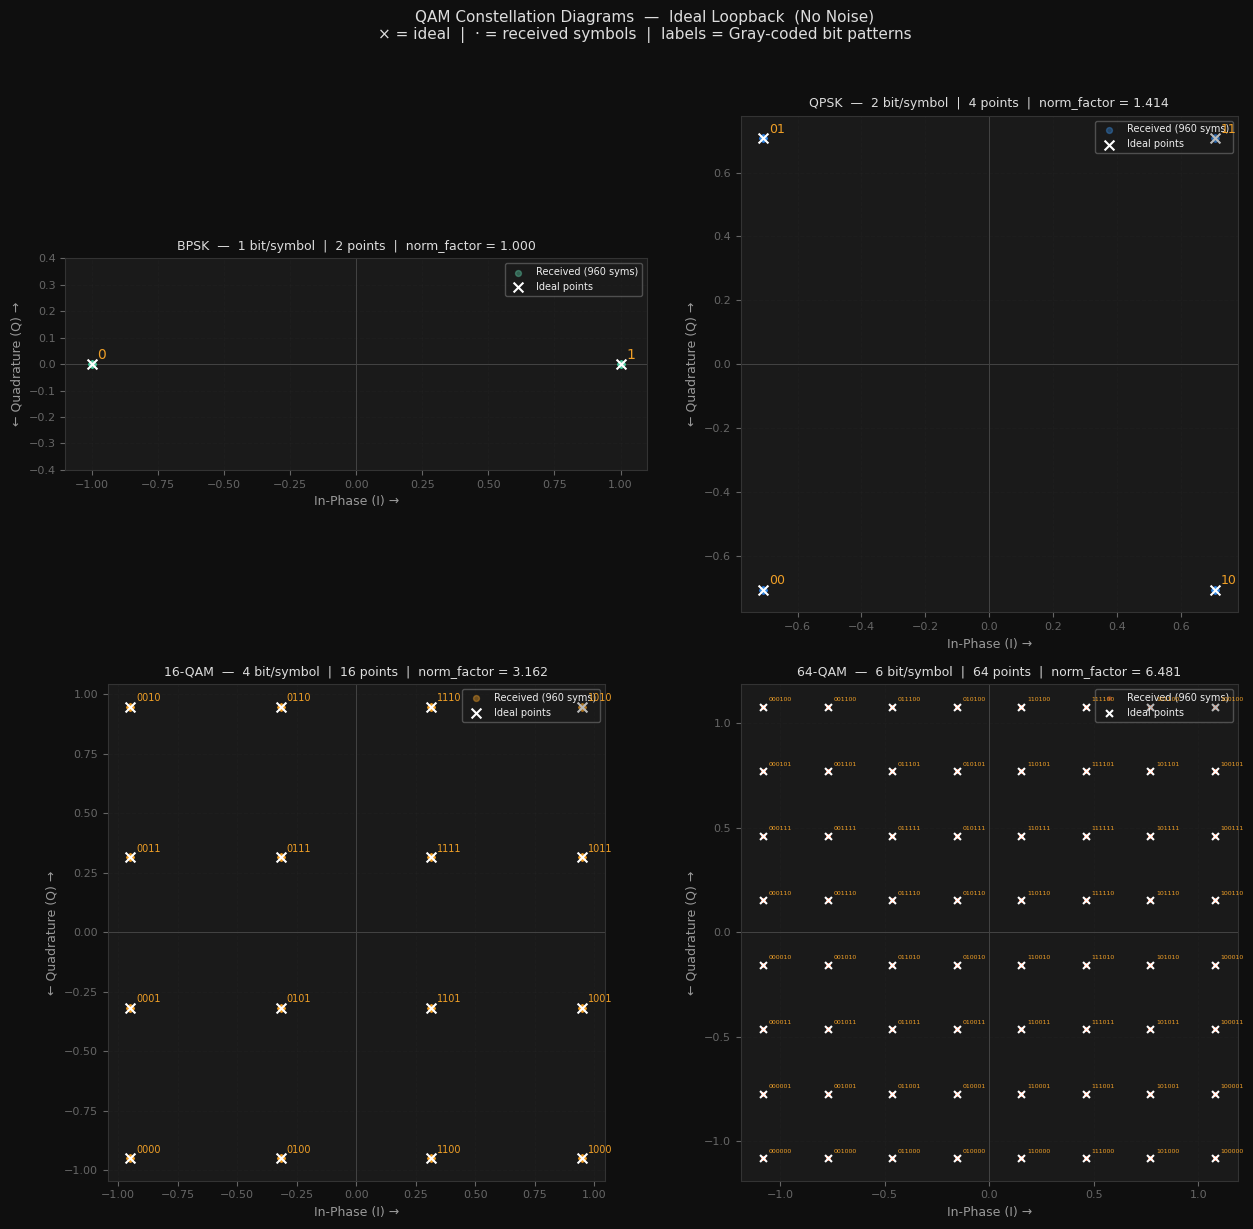

✓ Saved → constellations.png


In [7]:
# ─── Cell 7: Constellation Diagrams ──────────────────────────────────────────

def plot_constellations(results: dict):
    """
    Four-panel IQ constellation plot: one panel per QAM scheme.

    What you're seeing:
      × (white crosses) = ideal constellation points with their Gray-coded bit labels
      · (colored dots)  = received symbols after the demodulator's FFT + demapping

    In an ideal channel: every dot lands exactly on a cross.
    In Phase 3 (with AWGN noise): dots form clouds around each cross.
    The cloud radius grows as SNR falls. Decision boundaries are halfway between crosses.
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 12), facecolor='#0f0f0f')
    fig.suptitle(
        "QAM Constellation Diagrams  —  Ideal Loopback  (No Noise)\n"
        "× = ideal  |  · = received symbols  |  labels = Gray-coded bit patterns",
        fontsize=11, color='#ddd', y=1.02,
    )

    for ax, scheme in zip(axes.flatten(), QAMMapper.SCHEMES):
        ax.set_facecolor('#1a1a1a')
        mapper   = results[scheme]['mapper']
        rx_syms  = results[scheme]['rx_syms'].flatten()  # all received symbols
        M, bps   = mapper.M, mapper.bits_per_symbol
        color    = QAMMapper.COLORS[scheme]

        # ── Received symbol scatter ───────────────────────────────────────
        ax.scatter(
            rx_syms.real, rx_syms.imag,
            s     = 6 if M > 16 else 18,
            alpha = 0.40,
            c     = color,
            zorder= 3,
            label = f'Received ({len(rx_syms)} syms)',
        )

        # ── Ideal constellation points ────────────────────────────────────
        ideal_syms, labels = mapper.get_constellation_points()
        ax.scatter(
            ideal_syms.real, ideal_syms.imag,
            s          = 50 if M <= 16 else 25,
            c          = 'white',
            marker     = 'x',
            linewidths = 1.5,
            zorder     = 5,
            label      = 'Ideal points',
        )

        # ── Bit labels ────────────────────────────────────────────────────
        fs = {2: 10, 4: 9, 16: 7, 64: 4.5}[M]
        for sym, lbl in zip(ideal_syms, labels):
            ax.annotate(
                lbl, (sym.real, sym.imag),
                textcoords = 'offset points',
                xytext     = (4, 4),
                fontsize   = fs,
                color      = '#EF9F27',
                zorder     = 6,
            )

        # ── Axes decoration ───────────────────────────────────────────────
        ax.axhline(0, color='#444', lw=0.7)
        ax.axvline(0, color='#444', lw=0.7)
        ax.grid(True, alpha=0.15)
        ax.set_aspect('equal')
        ax.tick_params(colors='#666', labelsize=8)
        ax.set_xlabel('In-Phase (I) →', fontsize=9, color='#999')
        ax.set_ylabel('← Quadrature (Q) →', fontsize=9, color='#999')
        for sp in ax.spines.values():
            sp.set_edgecolor('#333')

        # BPSK: Q axis is meaningless — tighten the y-range
        if scheme == 'BPSK':
            ax.set_ylim(-0.4, 0.4)

        ax.set_title(
            f"{scheme}  —  {bps} bit/symbol  |  {M} points  |  "
            f"norm_factor = {mapper.norm_factor:.3f}",
            color='#ddd', fontsize=9,
        )
        ax.legend(fontsize=7, loc='upper right', framealpha=0.3)

    plt.tight_layout()
    plt.savefig('constellations.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("✓ Saved → constellations.png")


plot_constellations(results)

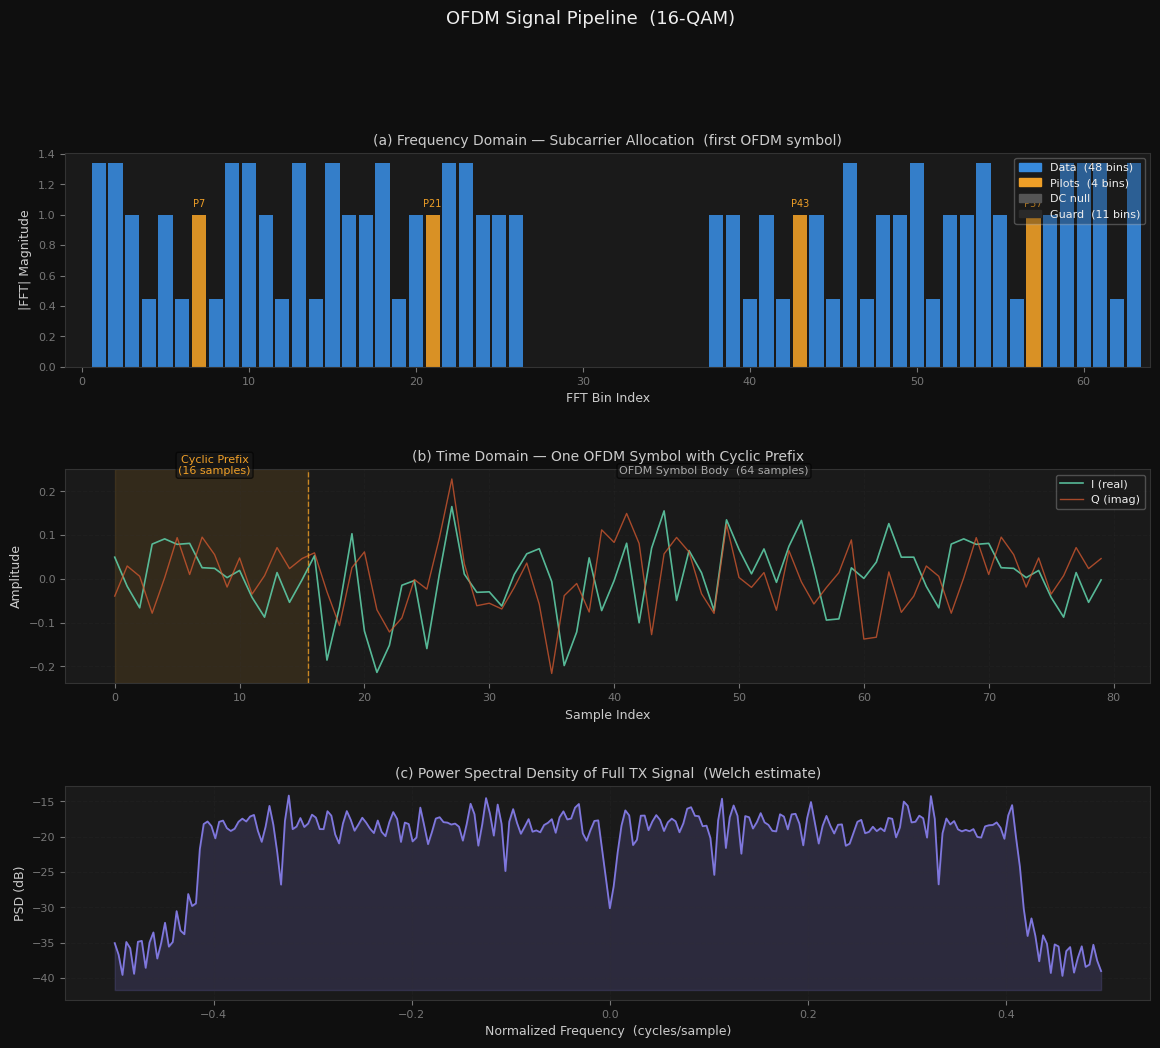

✓ Saved → ofdm_pipeline.png


In [8]:
# ─── Cell 8: Signal Pipeline Visualization ───────────────────────────────────
#
# Shows the 16-QAM signal at each stage of the pipeline:
#   (a) Frequency-domain frame — which bins carry what
#   (b) Time-domain OFDM symbol — the actual transmitted waveform + CP
#   (c) Power Spectral Density — what the signal looks like on a spectrum analyser

def plot_signal_pipeline(results: dict, cfg: OFDMConfig, scheme: str = '16-QAM'):

    tx_signal = results[scheme]['tx_signal']
    mapper    = results[scheme]['mapper']

    # Reconstruct the first OFDM symbol's frequency frame from the TX signal
    sym_dur    = cfg.symbol_duration
    one_symbol = tx_signal[:sym_dur]              # first complete OFDM symbol (with CP)
    time_body  = one_symbol[cfg.CP_len:]          # strip CP → N_fft samples
    freq_frame = np.fft.fft(time_body)            # reconstruct frequency domain

    fig = plt.figure(figsize=(14, 11), facecolor='#0f0f0f')
    fig.suptitle(f"OFDM Signal Pipeline  ({scheme})",
                 fontsize=13, color='#eee', y=1.01)
    gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.48)

    # ── Panel A: Subcarrier Allocation ────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0])
    ax0.set_facecolor('#1a1a1a')

    bins = np.arange(cfg.N_fft)
    mag  = np.abs(freq_frame)

    # Colour each FFT bin by its role
    bar_colors = np.full(cfg.N_fft, '#2a2a2a', dtype=object)   # guard default
    for b in cfg.data_bins:   bar_colors[b] = '#378ADD'         # data
    for b in cfg.pilot_bins:  bar_colors[b] = '#EF9F27'         # pilots
    bar_colors[0] = '#555555'                                    # DC null

    ax0.bar(bins, mag, color=bar_colors, width=0.85, alpha=0.9)

    legend_patches = [
        mpatches.Patch(color='#378ADD', label=f'Data  ({cfg.N_data} bins)'),
        mpatches.Patch(color='#EF9F27', label=f'Pilots  ({cfg.N_pilots} bins)'),
        mpatches.Patch(color='#555555', label='DC null'),
        mpatches.Patch(color='#2a2a2a', label=f'Guard  ({cfg.N_guard - 1} bins)'),
    ]
    ax0.legend(handles=legend_patches, fontsize=8, loc='upper right', framealpha=0.3)
    ax0.set_title('(a) Frequency Domain — Subcarrier Allocation  (first OFDM symbol)',
                  color='#ccc', fontsize=10)
    ax0.set_xlabel('FFT Bin Index', fontsize=9)
    ax0.set_ylabel('|FFT| Magnitude', fontsize=9)
    ax0.tick_params(colors='#777', labelsize=8)
    ax0.set_xlim(-1, cfg.N_fft)
    for sp in ax0.spines.values(): sp.set_edgecolor('#333')

    # Annotate pilot positions
    for pb in cfg.pilot_bins:
        ax0.annotate(f'P{pb}', xy=(pb, mag[pb]),
                     xytext=(pb, mag[pb] + 0.05),
                     fontsize=7, color='#EF9F27', ha='center')

    # ── Panel B: Time-Domain Symbol with CP highlighted ───────────────────────
    ax1 = fig.add_subplot(gs[1])
    ax1.set_facecolor('#1a1a1a')

    t = np.arange(sym_dur)
    ax1.plot(t, one_symbol.real, color='#5DCAA5', lw=1.2, label='I (real)', alpha=0.9)
    ax1.plot(t, one_symbol.imag, color='#D85A30', lw=1.0, label='Q (imag)', alpha=0.75)

    # CP shading
    ax1.axvspan(0, cfg.CP_len - 0.5, alpha=0.12, color='#EF9F27')
    ax1.axvline(cfg.CP_len - 0.5, color='#EF9F27', lw=1.0, ls='--', alpha=0.8)

    ymax = np.max(np.abs(one_symbol)) * 0.85
    ax1.annotate(
        f'Cyclic Prefix\n({cfg.CP_len} samples)',
        xy=(cfg.CP_len / 2, ymax),
        ha='center', fontsize=8, color='#EF9F27',
        bbox=dict(boxstyle='round,pad=0.2', fc='#1a1a1a', alpha=0.6),
    )
    ax1.annotate(
        f'OFDM Symbol Body  ({cfg.N_fft} samples)',
        xy=(cfg.CP_len + cfg.N_fft / 2, ymax),
        ha='center', fontsize=8, color='#aaa',
        bbox=dict(boxstyle='round,pad=0.2', fc='#1a1a1a', alpha=0.6),
    )

    ax1.set_title('(b) Time Domain — One OFDM Symbol with Cyclic Prefix',
                  color='#ccc', fontsize=10)
    ax1.set_xlabel('Sample Index', fontsize=9)
    ax1.set_ylabel('Amplitude', fontsize=9)
    ax1.legend(fontsize=8, loc='upper right', framealpha=0.3)
    ax1.tick_params(colors='#777', labelsize=8)
    ax1.grid(True, alpha=0.2)
    for sp in ax1.spines.values(): sp.set_edgecolor('#333')

    # ── Panel C: Power Spectral Density of full TX stream ─────────────────────
    ax2 = fig.add_subplot(gs[2])
    ax2.set_facecolor('#1a1a1a')

    freqs_w, psd = scipy_signal.welch(tx_signal, nperseg=cfg.N_fft * 4,
                                       return_onesided=False)
    freqs_w = np.fft.fftshift(freqs_w)
    psd     = np.fft.fftshift(psd)
    psd_db  = 10 * np.log10(psd + 1e-14)

    ax2.plot(freqs_w, psd_db, color='#7F77DD', lw=1.3)
    ax2.fill_between(freqs_w, psd_db.min() - 2, psd_db, alpha=0.18, color='#7F77DD')
    ax2.set_title('(c) Power Spectral Density of Full TX Signal  (Welch estimate)',
                  color='#ccc', fontsize=10)
    ax2.set_xlabel('Normalized Frequency  (cycles/sample)', fontsize=9)
    ax2.set_ylabel('PSD (dB)', fontsize=9)
    ax2.tick_params(colors='#777', labelsize=8)
    ax2.grid(True, alpha=0.2)
    for sp in ax2.spines.values(): sp.set_edgecolor('#333')

    plt.savefig('ofdm_pipeline.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("✓ Saved → ofdm_pipeline.png")


plot_signal_pipeline(results, cfg, scheme='16-QAM')